<!-- # Proyecto Integrador
**Integrantes:** Sebastián Aucapiña, Bryan Montaguano -->

# Importar Librerías

In [17]:
# Sistema
import os
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Kaggle API
from kaggle.api.kaggle_api_extended import KaggleApi

# Machine Learning - Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

# Modelos - Regresión 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Modelos - Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Opcional: warnings off
warnings.filterwarnings("ignore")

In [ ]:
# Establecemos una semilla única que será usada en todos los modelos
mi_semilla : int = 14

# Extracción de Datos

Según la documentacíon de [Kaggle](https://www.kaggle.com/docs/api#authentication), existen distintas herramientas para obtener la información a través de la api; en este caso utilizamos la herramienta oficial [Kagglehub](https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas) para obtener la información del dataset.

Dentro de Kaggle generamos una API Token la cual se ubica dentro de los secrets de los codespaces en el repositorio para la conexión con la API, evitando exponer el token de forma pública en el código.

In [3]:
os.environ['KAGGLE_KEY'] = os.environ['KAGGLE_API_TOKEN']
os.environ['KAGGLE_KEY'] = os.environ['KAGGLE_USERNAME']

# Inicializar la API y autenticar
api = KaggleApi()
api.authenticate()

In [4]:
# Dataset: zynicide/wine-reviews (solo ejemplo, reemplaza con el que necesites)
dataset_name = 'maharshipandya/-spotify-tracks-dataset'
download_path = './data'

# Descarga y descomprime automáticamente
api.dataset_download_files(dataset_name, path=download_path, unzip=True)

print("¡Dataset descargado en:", download_path, "!")

Dataset URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
¡Dataset descargado en: ./data !


In [5]:
# Transformar el CSV
df = pd.read_csv("./data/dataset.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
# Imprimimos informacíon Básica sobre el Dataset Mediante
# las funciones .columns, .shape y los tipos de datos del Dataframe
print(f"Las variables dentro del dataset son:\n{df.columns}")
print("-" * 100)
print(f"El tamaño del dataset utilizado es (Filas / Columnas): {df.shape}")
print("-" * 100)
print("Variables obtenidas y sus tipos de datos:")
df.info()

Las variables dentro del dataset son:
Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')
----------------------------------------------------------------------------------------------------
El tamaño del dataset utilizado es (Filas / Columnas): (114000, 21)
----------------------------------------------------------------------------------------------------
Variables obtenidas y sus tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           11399

# Limpieza y Pre-Procesamiento

In [8]:
# Estadísticas descriptivas de las variables numéricas del dataset (danceability, energy, loudness, etc.)
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [9]:
# Ver cuántos nulos hay por columna
df_cleaned = df.isnull().sum()

df_cleaned[df_cleaned > 0]

artists       1
album_name    1
track_name    1
dtype: int64

In [10]:
# Eliminamos los nulos visualizados previamente
df_cleaned = df.dropna()

Verificamos que el dataset contiene pocos valores nulos en pocas columnas, por lo cual eliminar los 3 registros dentro del dataset no representará un cambio significativo para la ejecución y rendimiento del modelo.

In [11]:
# Verificamos si existen duplicados dentro del dataset con la funcíon duplicated
print(f"Cantidad de duplicados en el dataset:\n{df_cleaned.duplicated().sum()}")

Cantidad de duplicados en el dataset:
0


Se pudo visualizar mediante la función de *duplicated* que el dataset no contiene elementos duplicados; esto significa que en ninguna columna se visualizarán elementos duplicados que puedan afectar al modelo inicialmente.

# Visualización de Relaciones

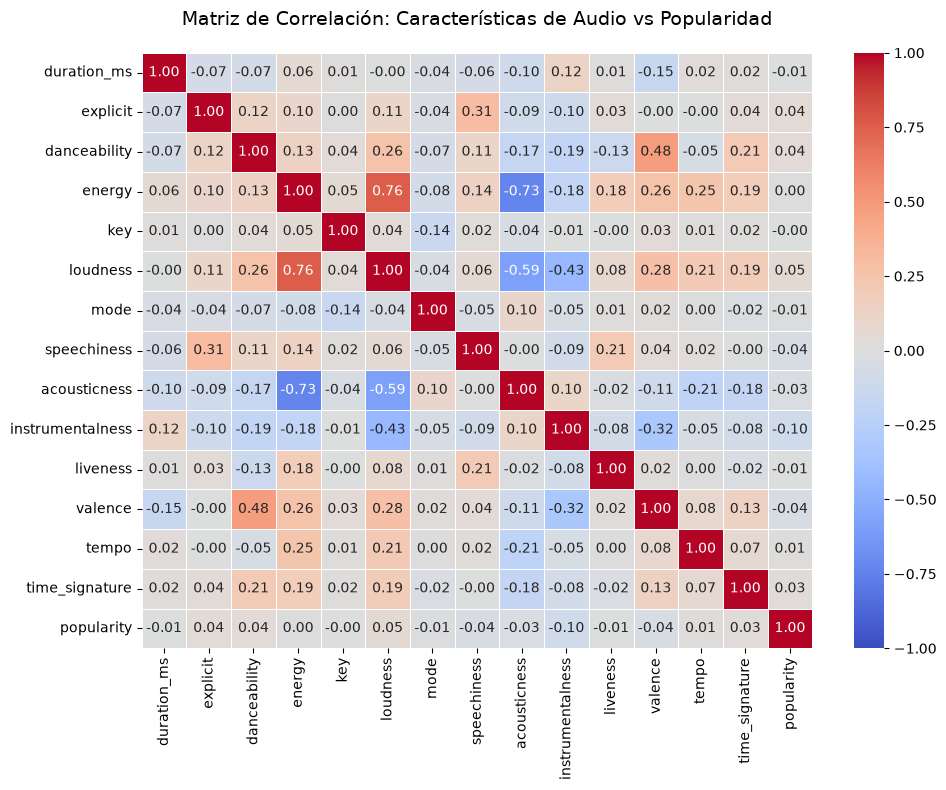

In [12]:
# 1. Matriz de Correlación
plt.figure(figsize=(10, 8))

# Esta es la lista de las features que deseamos comparar con la feature objetivo
features_list : list = [
    'duration_ms', 'explicit', 'danceability', 'energy',
    'key', 'loudness', 'mode', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 
    'tempo', 'time_signature'
]

# Calculamos la correlación de las features + el target
columnas_analisis = features_list + ['popularity']
matriz_corr = df_cleaned[columnas_analisis].corr()

# Creamos el mapa de calor
sns.heatmap(
    matriz_corr, 
    annot=True,          # Muestra los números dentro de cada celda
    cmap="coolwarm",     # Escala de colores (azul negativo, rojo positivo)
    fmt=".2f",           # Redondea a 2 decimales
    linewidths=0.5,      # Separa las celdas con una línea delgada
    vmin=-1, vmax=1      # Forzar los límites de la escala
)

plt.title("Matriz de Correlación: Características de Audio vs Popularidad", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [13]:
porcentaje_ceros = (df['popularity'] == 0).mean() * 100
print(f"{porcentaje_ceros:.2f}%")

14.05%


# 5. Hipótesis del Proyecto

---

## 5.1 Hipótesis Principal

> **H1:** Las dimensiones intrínsecas de las características matemáticas de audio (tales como `danceability`, `energy`, `loudness`, `valence`, entre otras) presentan una capacidad predictiva estadísticamente significativa sobre el índice de popularidad (`popularity`) de un track en Spotify, permitiendo modelar su comportamiento mediante algoritmos de regresión supervisada lineales y de ensamble.

En términos simples: **creemos que sí se puede predecir qué tan popular será una canción basándonos únicamente en sus propiedades sonoras**, sin necesidad de saber quién la canta ni en qué año salió.

Variable Objetivo ($Y$): 
- popularity (Métrica continua de 0 a 100).
- Variables de Entrada ($X$): Características acústicas y temporales extraídas del procesamiento de la señal de audio (excluyendo identificadores únicos de texto como `track_id`, `artists`, `album_name`, `track_name`).

# 6. Modelos Seleccionados

---

En esta sección definimos los tres modelos que vamos a aplicar sobre el dataset procesado.

## Tipo de problema

La variable objetivo `popularity` es un entero continuo entre 0 y 100, por lo que el problema es primariamente de **regresión**. No obstante, según las investigaciones realizadas en clase se logró identificar que los modelos de **clasificación** tuvieron un mejor resultado para clasificar una canción como popular/no pupular basados en un umbral específico. De esta manera, tomando en cuenta las justificaciones académicas, se desarrollarán los modelos usando estos dos enfoques para visualizar los resultados. 

---

## Modelo 1: Regresión Lineal Múltiple

**Tipo:** Regresión supervisada (Baseline)

**Justificación:** Es el punto de partida natural para cualquier problema de predicción numérica. Aunque asume linealidad matemática estricta entre las variables, nos sirve como **baseline** institucional para comparar el rendimiento de los modelos basados en árboles. Si un modelo sofisticado no supera a la regresión lineal, la complejidad matemática adicional no estaría justificada. Además, los coeficientes del modelo nos permiten interpretar de forma directa y transparente el impacto positivo o negativo de cada característica musical sobre la popularidad.

**Variables de entrada previstas:** `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `time_signature`, `duration_ms`, `explicit` (previamente estandarizadas mediante `StandardScaler`).

**Librería:** `sklearn.linear_model.LinearRegression`

---

## Modelo 2: Random Forest Regressor (Modelo Estrella)

**Tipo:** Ensemble supervisado basado en Bagging (Árboles de Decisión en Paralelo)

**Justificación:** Seleccionado como el **modelo estrella del proyecto** respaldado por la literatura científica analizada, la cual demuestra que los algoritmos basados en árboles obtienen el mejor desempeño en el análisis de audio de Spotify. Al construir múltiples árboles de decisión independientes en paralelo y promediar sus predicciones, reduce drásticamente el riesgo de sobreajuste (*overfitting*). Este modelo es ideal para nuestro dataset ya que maneja de forma nativa las relaciones no lineales complejas y la dispersión reflejada en la matriz de correlación inicial, permitiéndonos además extraer el *Feature Importance* para mapear qué variables determinan el éxito de un track.

**Variables de entrada previstas:** Las mismas características musicales que el Modelo 1.

**Librería:** `sklearn.ensemble.RandomForestRegressor`

---

## Modelo 3: Gradient Boosting (XGBoost)

**Tipo:** Ensemble supervisado basado en Boosting (Árboles de Decisión Secuenciales)

**Justificación:** Se incluye como un algoritmo de optimización avanzada para competir directamente contra nuestro modelo estrella. A diferencia de Random Forest, XGBoost construye los árboles de manera **secuencial**, donde cada nuevo árbol minimiza y corrige los errores de optimización del árbol anterior mediante el descenso de gradiente. Lo seleccionamos debido a su alta eficiencia computacional con grandes volúmenes de datos tabulares (Big Data) y su capacidad para detectar patrones ultra complejos no lineales en las señales acústicas que la regresión lineal o un bosque aleatorio básico podrían omitir.

**Variables de entrada previstas:** Las mismas características musicales que el Modelo 1, aplicando ajuste de hiperparámetros (`n_estimators`, `max_depth`, `learning_rate`).

**Librería:** `xgboost.XGBRegressor`

---

## Resumen comparativo de Arquitecturas

| Modelo | Tipo | Interpretabilidad | Capacidad No Lineal | Rol en el Proyecto |
|--------|------|-------------------|---------------------|--------------------|
| **Regresión Lineal Múltiple** | Regresión Lineal | Alta (Coeficientes directos) | Baja | Baseline Comparativo |
| **Random Forest Regressor** | Ensamble (Bagging) | Media (*Feature Importance*) | Alta | **Modelo Estrella (Científico)** |
| **XGBoost Regressor** | Ensamble (Boosting) | Baja (Caja Negra) | Muy Alta | Optimización y Máximo Rendimiento |

---


In [18]:
# ==========================================
# PREPROCESAMIENTO, ESCALADO Y MODELADO
# ==========================================

# Características musicales explicativas
caracteristicas_musicales = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
    'time_signature', 'duration_ms', 'explicit'
]

# Variables X e y
X = df_cleaned[caracteristicas_musicales]
y = df_cleaned['popularity']

# ==========================================
# 1. DIVISIÓN TRAIN / TEST
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=mi_semilla
)

# ==========================================
# 2. ESCALADO
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("==========================================")
print("DIMENSIONES DEL DATASET")
print("==========================================")
print(f"Train: {X_train_scaled.shape}")
print(f"Test : {X_test_scaled.shape}")

# ==========================================
# 3. MODELOS
# ==========================================
modelo_lr = LinearRegression()

modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=mi_semilla,
    n_jobs=-1
)

modelo_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=mi_semilla,
    n_jobs=-1
)

# ==========================================
# 4. ENTRENAMIENTO
# ==========================================
print("\nEntrenando Regresión Lineal...")
modelo_lr.fit(X_train_scaled, y_train)

print("Entrenando Random Forest...")
modelo_rf.fit(X_train_scaled, y_train)

print("Entrenando XGBoost...")
modelo_xgb.fit(X_train_scaled, y_train)

# ==========================================
# 5. PREDICCIONES
# ==========================================
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test_scaled)
y_pred_xgb = modelo_xgb.predict(X_test_scaled)

# ==========================================
# 6. MÉTRICAS
# ==========================================
def calcular_metricas(nombre_modelo, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    return {
        "Modelo": nombre_modelo,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R2": round(r2, 4)
    }

resultados = pd.DataFrame([
    calcular_metricas("Regresión Lineal", y_test, y_pred_lr),
    calcular_metricas("Random Forest", y_test, y_pred_rf),
    calcular_metricas("XGBoost", y_test, y_pred_xgb)
]).set_index("Modelo")

display(resultados)

DIMENSIONES DEL DATASET
Train: (91199, 14)
Test : (22800, 14)

Entrenando Regresión Lineal...
Entrenando Random Forest...
Entrenando XGBoost...


,RMSE,MAE,R2
Modelo,,,
Regresión Lineal,21.8548,18.2080,0.0257
Random Forest,14.9432,10.6058,0.5445
XGBoost,20.1142,16.3490,0.1747


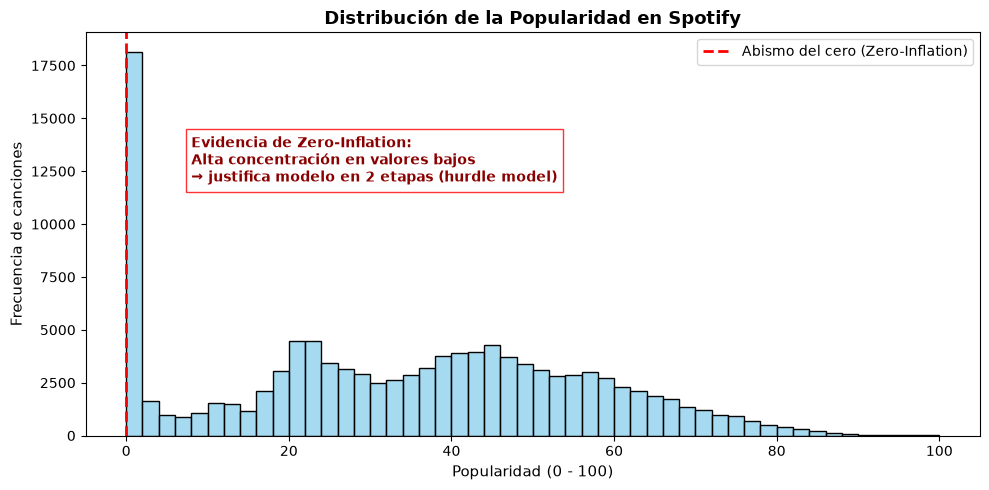

In [21]:
# =====================================================================
# VISUALIZACIÓN: HISTOGRAMA - EVIDENCIA DE ZERO-INFLATION
# =====================================================================

plt.figure(figsize=(10, 5))

# Histograma de popularidad
sns.histplot(
    df_cleaned['popularity'],
    bins=50,
    kde=False,
    color='skyblue',
    edgecolor='black'
)

# Línea del cero (referencia del “abismo”)
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Abismo del cero (Zero-Inflation)'
)

# Título y etiquetas
plt.title('Distribución de la Popularidad en Spotify', fontsize=13, fontweight='bold')
plt.xlabel('Popularidad (0 - 100)', fontsize=11)
plt.ylabel('Frecuencia de canciones', fontsize=11)

# Texto explicativo (mejor alineado a tu modelo)
plt.text(
    8,
    df_cleaned['popularity'].value_counts().max() * 0.75,
    "Evidencia de Zero-Inflation:\n"
    "Alta concentración en valores bajos\n"
    "→ justifica modelo en 2 etapas (hurdle model)",
    color='darkred',
    weight='bold',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='red')
)

plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# =====================================================================
# OBJETIVO 1: CLASIFICACIÓN BINARIA - ¿SALE DEL CERO?
# =====================================================================

# 1. Definición de características musicales
caracteristicas_musicales = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
    'time_signature', 'duration_ms', 'explicit'
]

# 2. Asegurar tipo correcto para 'explicit'
if 'explicit' in df_cleaned.columns and df_cleaned['explicit'].dtype == 'bool':
    df_cleaned['explicit'] = df_cleaned['explicit'].astype(int)

# 3. Variables X e Y
X = df_cleaned[caracteristicas_musicales]

y_binario = np.where(df_cleaned['popularity'] > 0, 1, 0)

# =====================================================================
# 4. SPLIT (CON SEMILLA GLOBAL)
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binario,
    test_size=0.2,
    random_state=mi_semilla,
    stratify=y_binario
)

# =====================================================================
# 5. ESCALADO
# =====================================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*60)
print("INFORMACIÓN DE CONTROL DE DATOS (OBJETIVO 1)")
print("="*60)
print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape : {X_test_scaled.shape}")
print(f"Distribución clases [0,1]: {np.bincount(y_train)}")
print("-"*60)

# =====================================================================
# 6. MODELOS
# =====================================================================
modelo_lr = LogisticRegression(
    class_weight='balanced',
    random_state=mi_semilla,
    max_iter=1000
)

modelo_dt = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=mi_semilla
)

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=mi_semilla,
    n_jobs=-1
)

# =====================================================================
# 7. ENTRENAMIENTO
# =====================================================================
print("Entrenando Regresión Logística...")
modelo_lr.fit(X_train_scaled, y_train)

print("Entrenando Árbol de Decisión...")
modelo_dt.fit(X_train_scaled, y_train)

print("Entrenando Random Forest...")
modelo_rf.fit(X_train_scaled, y_train)

# =====================================================================
# 8. PREDICCIONES
# =====================================================================
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_pred_dt = modelo_dt.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test_scaled)

# =====================================================================
# 9. EVALUACIÓN
# =====================================================================
def evaluar_clasificador_binario(nombre_modelo, y_real, y_pred):
    return {
        'Modelo': nombre_modelo,
        'Accuracy': round(accuracy_score(y_real, y_pred), 4),
        'Precision': round(precision_score(y_real, y_pred), 4),
        'Recall': round(recall_score(y_real, y_pred), 4),
        'F1-Score': round(f1_score(y_real, y_pred), 4)
    }

res_fase1 = [
    evaluar_clasificador_binario('Regresión Logística', y_test, y_pred_lr),
    evaluar_clasificador_binario('Árbol de Decisión', y_test, y_pred_dt),
    evaluar_clasificador_binario('Random Forest', y_test, y_pred_rf)
]

df_res_fase1 = pd.DataFrame(res_fase1).set_index('Modelo')

display(df_res_fase1)

INFORMACIÓN DE CONTROL DE DATOS (OBJETIVO 1)
Train shape: (91199, 14)
Test shape : (22800, 14)
Distribución clases [0,1]: [12815 78384]
------------------------------------------------------------
Entrenando Regresión Logística...
Entrenando Árbol de Decisión...
Entrenando Random Forest...


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.5265,0.8984,0.5064,0.6477
Árbol de Decisión,0.5793,0.9144,0.5632,0.6971
Random Forest,0.9418,0.9654,0.9670,0.9662


In [20]:
# =====================================================================
# OBJETIVO 2: HIT PREDICTION CONDICIONAL (TOP 20%)
# =====================================================================

# ---------------------------------------------------------------------
# 1. FILTRADO: solo canciones con interacción
# ---------------------------------------------------------------------
df_pop = df_cleaned[df_cleaned["popularity"] > 0].copy()

# ---------------------------------------------------------------------
# 2. DEFINICIÓN DEL TARGET (HIT = TOP 20%)
# ---------------------------------------------------------------------
threshold = df_pop["popularity"].quantile(0.80)
df_pop["hit"] = (df_pop["popularity"] >= threshold).astype(int)

# ===================== PRINTS DE CONTROL =====================
print("="*60)
print("OBJETIVO 2 - INFORMACIÓN DEL DATASET")
print("="*60)
print(f"Threshold (Top 20%): {threshold:.2f}")
print(f"Distribución de clases [No Hit, Hit]: {np.bincount(df_pop['hit'])}")
print("-"*60)
print("Entrenando modelos de HIT prediction...\n")

# ---------------------------------------------------------------------
# 3. VARIABLES INDEPENDIENTES
# ---------------------------------------------------------------------
caracteristicas_musicales = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
    'time_signature', 'duration_ms', 'explicit'
]

X = df_pop[caracteristicas_musicales]
y = df_pop["hit"].to_numpy()

# ---------------------------------------------------------------------
# 4. SPLIT
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=mi_semilla,
    stratify=y
)

# ---------------------------------------------------------------------
# 5. ESCALADO
# ---------------------------------------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------------------------------------------------
# 6. MODELOS
# ---------------------------------------------------------------------
modelo_dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=mi_semilla
)

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=mi_semilla,
    n_jobs=-1
)

modelo_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=mi_semilla,
    n_jobs=-1,
    eval_metric="logloss"
)

# ---------------------------------------------------------------------
# 7. ENTRENAMIENTO
# ---------------------------------------------------------------------
modelo_dt.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)
modelo_xgb.fit(X_train, y_train)

# ---------------------------------------------------------------------
# 8. PREDICCIONES
# ---------------------------------------------------------------------
pred_dt = modelo_dt.predict(X_test)
pred_rf = modelo_rf.predict(X_test)
pred_xgb = modelo_xgb.predict(X_test)

# ---------------------------------------------------------------------
# 9. MÉTRICAS
# ---------------------------------------------------------------------
def evaluar(nombre, y_true, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4)
    }

resultados = pd.DataFrame([
    evaluar("Decision Tree", y_test, pred_dt),
    evaluar("Random Forest", y_test, pred_rf),
    evaluar("XGBoost", y_test, pred_xgb)
]).set_index("Modelo")

# ===================== OUTPUT FINAL =====================
print("\n" + "="*60)
print("RESULTADOS - OBJETIVO 2 (HIT PREDICTION)")
print("="*60)

resultados

OBJETIVO 2 - INFORMACIÓN DEL DATASET
Threshold (Top 20%): 56.00
Distribución de clases [No Hit, Hit]: [77435 20545]
------------------------------------------------------------
Entrenando modelos de HIT prediction...


RESULTADOS - OBJETIVO 2 (HIT PREDICTION)


,Accuracy,Precision,Recall,F1
Modelo,,,,
Decision Tree,0.7911,0.5889,0.0129,0.0252
Random Forest,0.8852,0.9178,0.4972,0.6450
XGBoost,0.7973,0.7306,0.0528,0.0985


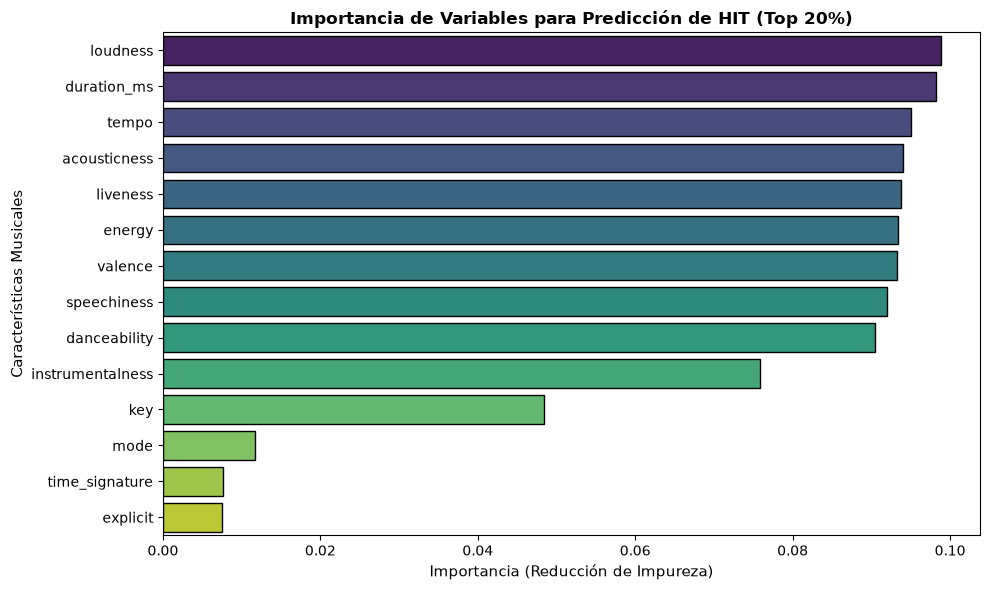

Ranking de importancia de variables para HIT prediction:


,Característica,Importancia
0,loudness,0.098857
1,duration_ms,0.098175
2,tempo,0.095009
3,acousticness,0.094006
4,liveness,0.093782
5,energy,0.093342
6,valence,0.093311
7,speechiness,0.092017
8,danceability,0.090449
9,instrumentalness,0.075792


In [22]:
# =====================================================================
# ANÁLISIS DE IMPORTANCIA DE VARIABLES (HIT TOP 20%)
# =====================================================================

# 1. Importancias del modelo Random Forest (Fase 2)
importancias_hit = modelo_rf.feature_importances_

# 2. DataFrame ordenado
df_importancia_hit = pd.DataFrame({
    'Característica': caracteristicas_musicales,
    'Importancia': importancias_hit
}).sort_values(by='Importancia', ascending=False)

# 3. Visualización
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_importancia_hit,
    x='Importancia',
    y='Característica',
    palette='viridis',
    edgecolor='black'
)

plt.title(
    'Importancia de Variables para Predicción de HIT (Top 20%)',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Importancia (Reducción de Impureza)', fontsize=11)
plt.ylabel('Características Musicales', fontsize=11)

plt.tight_layout()
plt.show()

# 4. Ranking numérico
print("Ranking de importancia de variables para HIT prediction:")
display(df_importancia_hit.reset_index(drop=True))

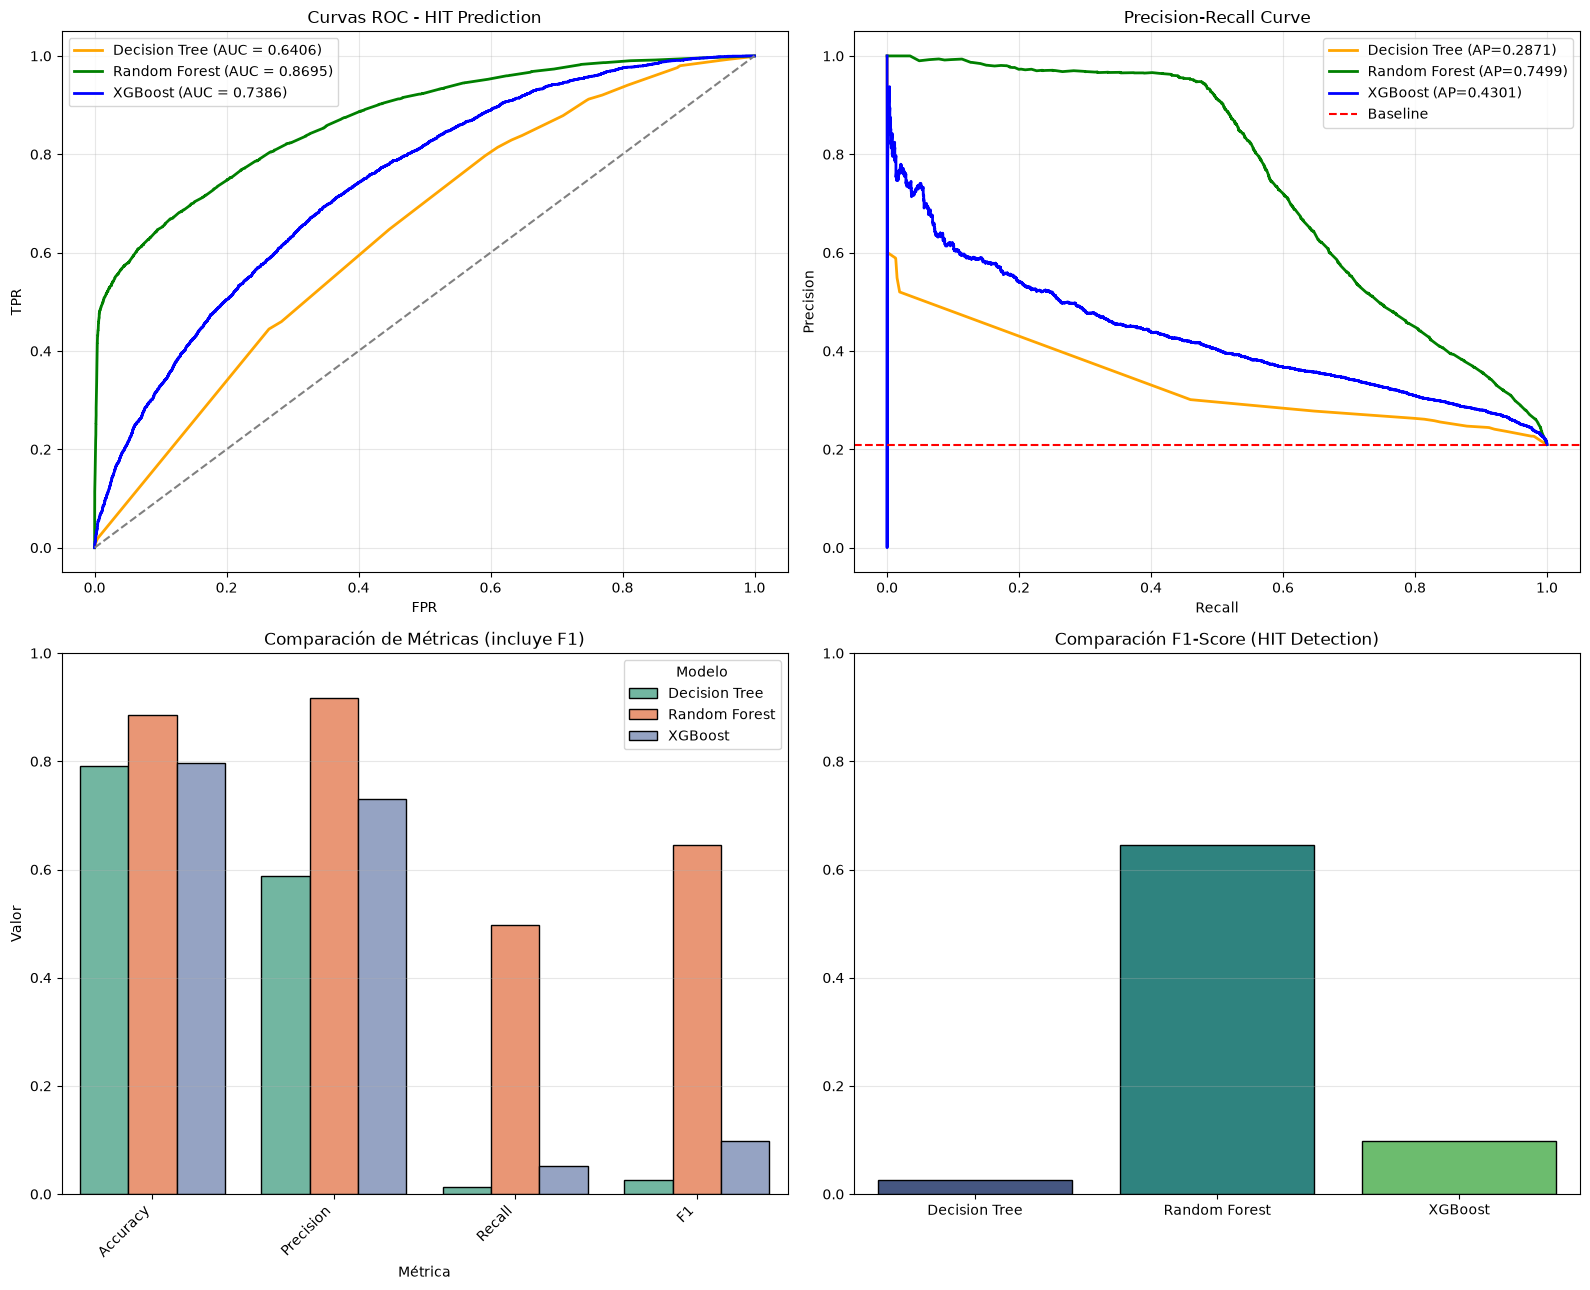

In [24]:
# =====================================================================
# EVALUACIÓN AVANZADA Y DIAGNÓSTICO DE MODELOS (HIT PREDICTION)
# =====================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

labels_hit = ['No Hit (80%)', 'Hit (20%)']

# ============================================================
# GRÁFICO 1: CURVAS ROC
# ============================================================

prob_dt = modelo_dt.predict_proba(X_test)[:, 1]
prob_rf = modelo_rf.predict_proba(X_test)[:, 1]
prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

modelos_lista = [
    (prob_dt, 'Decision Tree', 'orange'),
    (prob_rf, 'Random Forest', 'green'),
    (prob_xgb, 'XGBoost', 'blue')
]

for prob, nombre, color in modelos_lista:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    axes[0, 0].plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC = {roc_auc:.4f})')

axes[0, 0].plot([0, 1], [0, 1], '--', color='gray')
axes[0, 0].set_title('Curvas ROC - HIT Prediction')
axes[0, 0].set_xlabel('FPR')
axes[0, 0].set_ylabel('TPR')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# ============================================================
# GRÁFICO 2: PRECISION-RECALL
# ============================================================

for prob, nombre, color in modelos_lista:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[0, 1].plot(recall, precision, color=color, lw=2, label=f'{nombre} (AP={ap:.4f})')

axes[0, 1].axhline(y=np.mean(y_test), color='red', linestyle='--', label='Baseline')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ============================================================
# GRÁFICO 3: MÉTRICAS EN BARRAS (INCLUYE F1)
# ============================================================

df_plot = resultados.reset_index().melt(
    id_vars='Modelo',
    var_name='Métrica',
    value_name='Valor'
)

sns.barplot(
    x='Métrica',
    y='Valor',
    hue='Modelo',
    data=df_plot,
    palette='Set2',
    edgecolor='black',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Comparación de Métricas (incluye F1)')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_xticklabels(
    axes[1, 0].get_xticklabels(),
    rotation=45,
    ha='right'
)
axes[1, 0].legend(title='Modelo')

# ============================================================
# GRÁFICO 4: F1 SCORE SOLO (RECOMENDADO)
# ============================================================

f1_scores = [
    f1_score(y_test, pred_dt),
    f1_score(y_test, pred_rf),
    f1_score(y_test, pred_xgb)
]

sns.barplot(
    x=['Decision Tree', 'Random Forest', 'XGBoost'],
    y=f1_scores,
    palette='viridis',
    edgecolor='black',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Comparación F1-Score (HIT Detection)')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

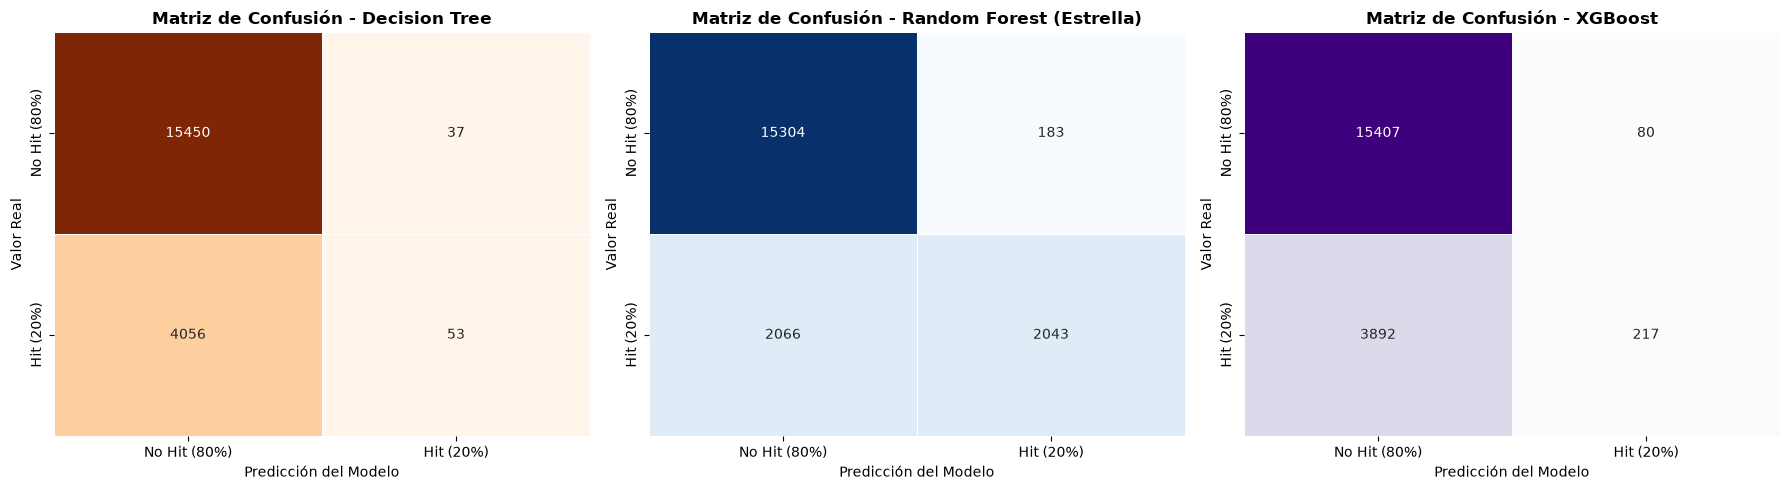

In [23]:
# =====================================================================
# MATRICES DE CONFUSIÓN - COMPARATIVA MODELOS (HIT TOP 20%)
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Etiquetas del problema HIT
labels_hit = ['No Hit (80%)', 'Hit (20%)']

# Configuración de modelos
matrices_config = [
    (y_test, pred_dt, 'Decision Tree', 'Oranges', axes[0]),
    (y_test, pred_rf, 'Random Forest (Estrella)', 'Blues', axes[1]),
    (y_test, pred_xgb, 'XGBoost', 'Purples', axes[2])
]

# Renderizado
for y_real, y_pred, nombre, cmap, ax in matrices_config:
    
    cm = confusion_matrix(y_real, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        ax=ax,
        xticklabels=labels_hit,
        yticklabels=labels_hit,
        edgecolor='gray',
        linewidths=0.5,
        cbar=False
    )
    
    ax.set_title(f'Matriz de Confusión - {nombre}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicción del Modelo')
    ax.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()